In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3D projection

## Question 5 — Gaussian filtering

2D Gaussian (unnormalized): $G(x,y)\propto \exp\!\left(-\dfrac{x^2+y^2}{2\sigma^2}\right)$ on a square grid centered at $(0,0)$. **Normalize** so all coefficients sum to **1**.

**Image:** grayscale from `images/runway.png` for parts (c) and (d).

In [2]:
def gaussian_kernel_2d(size: int, sigma: float) -> np.ndarray:
    """Discrete 2D Gaussian, odd size, mean at center, sum normalized to 1."""
    if size % 2 == 0:
        raise ValueError("size must be odd")
    r = size // 2
    ax = np.arange(-r, r + 1, dtype=np.float64)
    xx, yy = np.meshgrid(ax, ax)
    g = np.exp(-(xx * xx + yy * yy) / (2.0 * sigma * sigma))
    g /= g.sum()
    return g


# (a) 5×5, σ = 2
SIGMA = 2.0
K5 = gaussian_kernel_2d(5, SIGMA)
print("(a) Normalized 5×5 Gaussian kernel (σ = 2):")
np.set_printoptions(precision=6, suppress=True)
print(K5)
print(f"Sum of coefficients: {K5.sum():.10f}")

(a) Normalized 5×5 Gaussian kernel (σ = 2):
[[0.023247 0.033824 0.038328 0.033824 0.023247]
 [0.033824 0.049214 0.055766 0.049214 0.033824]
 [0.038328 0.055766 0.063191 0.055766 0.038328]
 [0.033824 0.049214 0.055766 0.049214 0.033824]
 [0.023247 0.033824 0.038328 0.033824 0.023247]]
Sum of coefficients: 1.0000000000


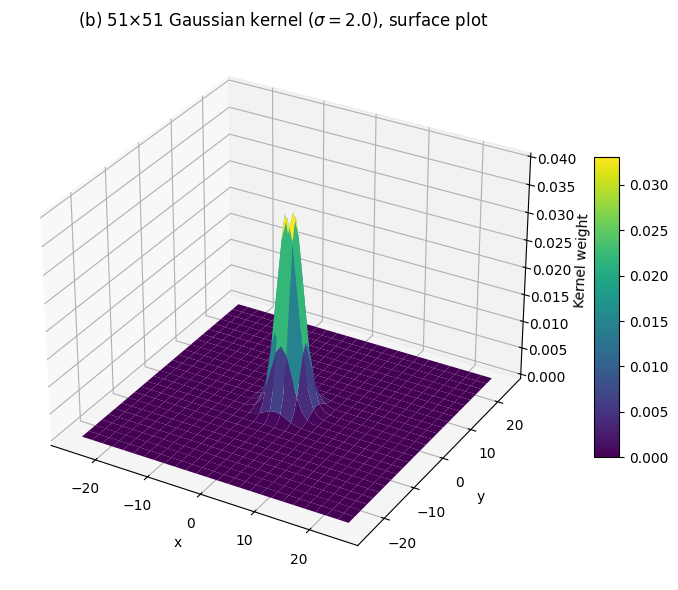

In [3]:
# (b) 51×51 kernel as 3D surface (heights = kernel values)
K51 = gaussian_kernel_2d(51, SIGMA)
r = 25
x = np.arange(-r, r + 1, dtype=np.float64)
X, Y = np.meshgrid(x, x)

fig = plt.figure(figsize=(8, 6))
ax3 = fig.add_subplot(111, projection="3d")
surf = ax3.plot_surface(X, Y, K51, cmap="viridis", linewidth=0, antialiased=True)
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("Kernel weight")
ax3.set_title(rf"(b) 51×51 Gaussian kernel ($\sigma={SIGMA}$), surface plot")
fig.colorbar(surf, shrink=0.55, aspect=12)
plt.tight_layout()
plt.show()

Max |manual − OpenCV|: 32


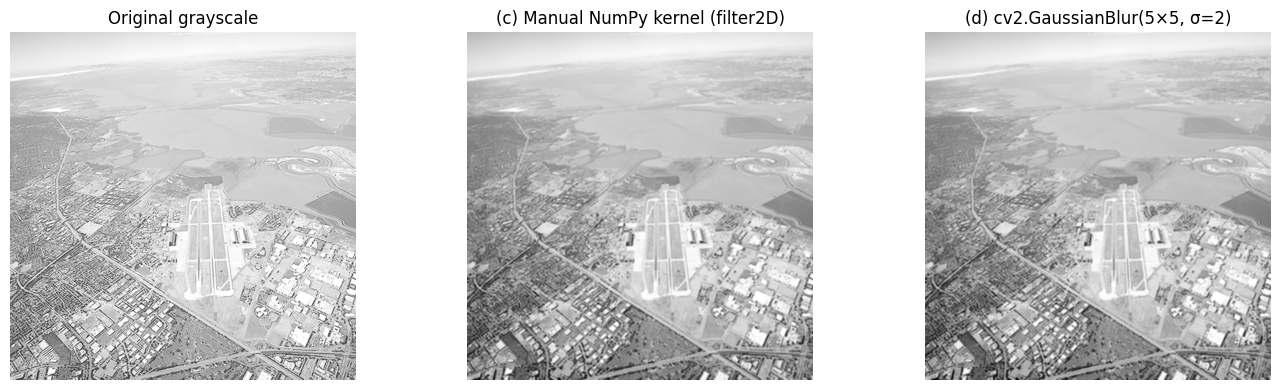

In [4]:
# (c) Manual kernel + (d) cv2.GaussianBlur — same σ and 5×5 support
path = "images/runway.png"
bgr = cv2.imread(path)
if bgr is None:
    raise FileNotFoundError(path)
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

# (c) correlation with reflected borders (standard for smoothing)
manual = cv2.filter2D(gray, ddepth=-1, kernel=K5, borderType=cv2.BORDER_REFLECT)

# (d) built-in: ksize (5,5), sigmaX = sigmaY = 2
opencv = cv2.GaussianBlur(gray, (5, 5), SIGMA)

diff = cv2.absdiff(manual, opencv)
print(f"Max |manual − OpenCV|: {diff.max()}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original grayscale")
axes[1].imshow(manual, cmap="gray")
axes[1].set_title("(c) Manual NumPy kernel (filter2D)")
axes[2].imshow(opencv, cmap="gray")
axes[2].set_title("(d) cv2.GaussianBlur(5×5, σ=2)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()